In [1]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
tf.__version__

'2.17.1'

In [3]:
%load_ext tensorboard

In [4]:
logdir='log'

In [5]:
# Carregar o conjunto de dados MNIST
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Redimensionar e normalizar as imagens
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))
train_images, test_images = train_images / 255.0, test_images / 255.0

# Definir as classes
classes=[0,1,2,3,4,5,6,7,8,9]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Construir o modelo
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
tensorboard_callback=tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

In [8]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Treinar o modelo
model.fit(x=train_images,
          y=train_labels,
          epochs=5,
          validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9024 - loss: 0.3186 - val_accuracy: 0.9799 - val_loss: 0.0618
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9854 - loss: 0.0479 - val_accuracy: 0.9891 - val_loss: 0.0330
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9900 - loss: 0.0321 - val_accuracy: 0.9856 - val_loss: 0.0417
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9920 - loss: 0.0235 - val_accuracy: 0.9921 - val_loss: 0.0245
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9942 - loss: 0.0177 - val_accuracy: 0.9894 - val_loss: 0.0351


In [9]:
# Fazer previsões
y_true = test_labels
y_pred = np.argmax(model.predict(test_images), axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [10]:
classes=[0,1,2,3,4,5,6,7,8,9]

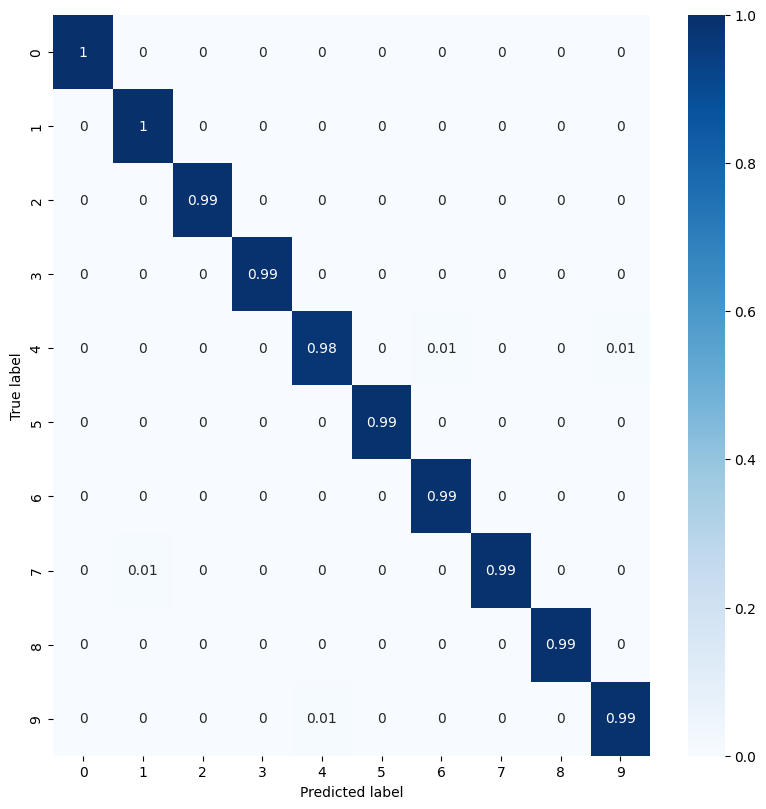

In [11]:
con_mat = tf.math.confusion_matrix(labels=y_true,predictions=y_pred).numpy()
con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)

con_mat_df = pd.DataFrame(con_mat_norm,
                          index = classes,
                          columns = classes)

figure = plt.figure(figsize=(8, 8))
sns.heatmap(con_mat_df, annot=True,cmap=plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


In [12]:
# Funções para calcular as métricas
def calcular_sensibilidade(vp, fn):
    return vp / (vp + fn)

def calcular_especificidade(vn, fp):
    return vn / (fp + vn)

def calcular_acuracia(vp, vn, fp, fn):
    n = vp + vn + fp + fn
    return (vp + vn) / n

def calcular_precisao(vp, fp):
    return vp / (vp + fp)

def calcular_fscore(precisao, sensibilidade):
    return 2 * (precisao * sensibilidade) / (precisao + sensibilidade)

In [13]:
# Calcular métricas para cada classe
for i in range(10):
    vp = con_mat[i, i]  # Verdadeiros positivos
    fp = con_mat[:, i].sum() - vp  # Falsos positivos
    fn = con_mat[i, :].sum() - vp  # Falsos negativos
    vn = con_mat.sum() - (vp + fp + fn)  # Verdadeiros negativos

    sensibilidade = calcular_sensibilidade(vp, fn)
    especificidade = calcular_especificidade(vn, fp)
    acuracia = calcular_acuracia(vp, vn, fp, fn)
    precisao = calcular_precisao(vp, fp)
    fscore = calcular_fscore(precisao, sensibilidade)

    print(f"Classe {i}:")
    print(f"  Sensibilidade (Recall): {sensibilidade:.2f}")
    print(f"  Especificidade: {especificidade:.2f}")
    print(f"  Acurácia: {acuracia:.2f}")
    print(f"  Precisão: {precisao:.2f}")
    print(f"  F-score: {fscore:.2f}")
    print()

Classe 0:
  Sensibilidade (Recall): 1.00
  Especificidade: 1.00
  Acurácia: 1.00
  Precisão: 0.99
  F-score: 0.99

Classe 1:
  Sensibilidade (Recall): 1.00
  Especificidade: 1.00
  Acurácia: 1.00
  Precisão: 0.99
  F-score: 0.99

Classe 2:
  Sensibilidade (Recall): 0.99
  Especificidade: 1.00
  Acurácia: 1.00
  Precisão: 0.99
  F-score: 0.99

Classe 3:
  Sensibilidade (Recall): 0.99
  Especificidade: 1.00
  Acurácia: 1.00
  Precisão: 1.00
  F-score: 0.99

Classe 4:
  Sensibilidade (Recall): 0.98
  Especificidade: 1.00
  Acurácia: 1.00
  Precisão: 0.99
  F-score: 0.99

Classe 5:
  Sensibilidade (Recall): 0.99
  Especificidade: 1.00
  Acurácia: 1.00
  Precisão: 0.99
  F-score: 0.99

Classe 6:
  Sensibilidade (Recall): 0.99
  Especificidade: 1.00
  Acurácia: 1.00
  Precisão: 0.98
  F-score: 0.99

Classe 7:
  Sensibilidade (Recall): 0.99
  Especificidade: 1.00
  Acurácia: 1.00
  Precisão: 0.99
  F-score: 0.99

Classe 8:
  Sensibilidade (Recall): 0.99
  Especificidade: 1.00
  Acurácia: 1.00